In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [9]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sys.path

['/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python310.zip',
 '/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10',
 '/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload',
 '',
 '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages',
 '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler']

In [4]:
adata = sc.read_h5ad("../../../../data/HGSOC/ALL_CELLS/all_cells_1p.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 10199 × 31815
    obs: 'percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score', 'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA', 'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'author_tumor_supersite', 'author_tumor_site', 'author_tumor_subsite', 'author_sort_parameters', 'author_therapy', 'author_procedure', 'author_procedure_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'author_cell_type_colors', 'citation', 'default_embedding', 'neighbors', 'organ

In [12]:
X_pca = adata.obsm["X_pca"]

n_neighbors = 15
min_dist = 0.1
metric = "euclidean"
random_state = 0

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    metric=metric,           # usually "euclidean"
    random_state=random_state
)

X_umap = reducer.fit_transform(X_pca)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cell_types = pd.Categorical(adata.obs["cell_type"])
categories = cell_types.categories

# Use tab20
base_cmap = plt.get_cmap("tab20")

# Ensure one-to-one mapping, repeat if >20
cat_colors = {}
for i, cat in enumerate(categories):
    cat_colors[cat] = base_cmap(i % 20)

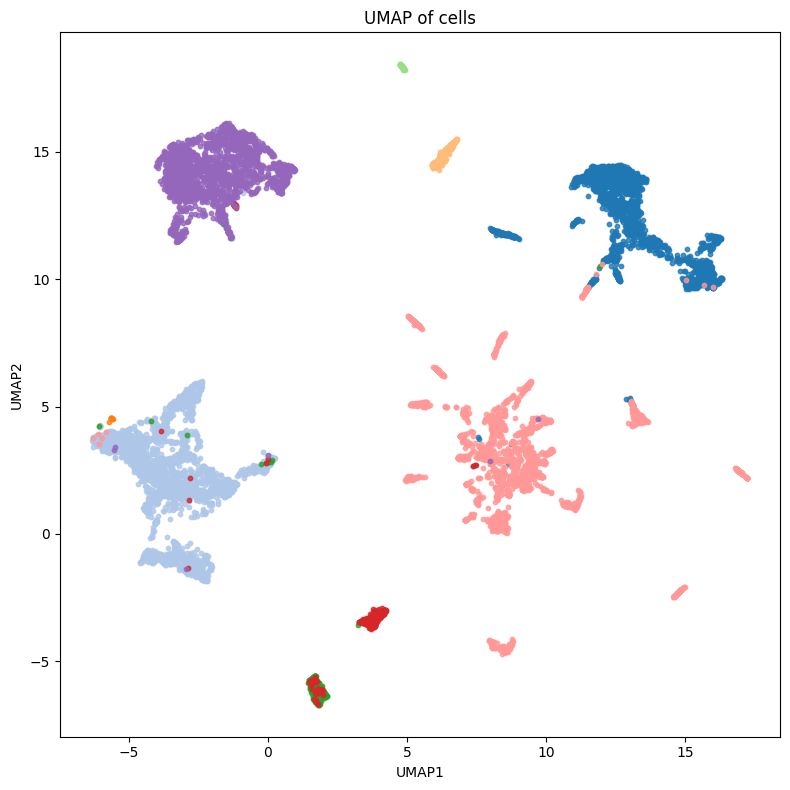

In [16]:
umap_coords = X_umap
plt.figure(figsize=(8,8))
for cat in categories:
    mask_cat = cell_types == cat
    plt.scatter(
        umap_coords[mask_cat, 0],
        umap_coords[mask_cat, 1],
        color=cat_colors[cat],
        s=10,
        alpha=0.8,
        label=cat
    )

# plt.legend(title="Cell type", loc='upper right', fontsize=8, title_fontsize=9)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of cells")
plt.tight_layout()
plt.show()
